In [2]:
import os
import re
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from infomap import Infomap

In [3]:
INPUT_DIR = "./competition"
OUTPUT_DIR = "./results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
N_TRIALS = 25
MARKOV_SCAN = np.logspace(-1, 1, 150)

In [4]:
def read_adjacency_csv(csv_path: str) -> nx.Graph:
    matrix = pd.read_csv(csv_path, header=None).values
    return nx.from_numpy_array(matrix)


def extract_known_k(filename: str):
    match = re.search(r"K=(\d+)", filename)
    return int(match.group(1)) if match else None


def save_partition(path: str, labels_zero_based: np.ndarray):
    with open(path, "w", encoding="utf-8") as f:
        for node_id, comm in enumerate(labels_zero_based, start=1):
            f.write(f"{node_id}, {comm + 1}\n")

In [9]:
def show_graph_basic(G: nx.Graph, title: str):
    degrees = [d for _, d in G.degree()]
    pos = nx.spring_layout(G, seed=SEED)

    plt.figure(figsize=(13, 6))

    plt.subplot(1, 2, 1)
    nx.draw(G, pos, node_size=60, edge_color="lightgray")
    plt.title(title)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.hist(degrees, bins=20)
    plt.title("Degree distribution")
    plt.xlabel("Degree")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

def show_communities(G: nx.Graph, labels: np.ndarray, title: str):
    pos = nx.spring_layout(G, seed=SEED)
    k = len(np.unique(labels))

    cmap = plt.colormaps.get_cmap("tab20").resampled(k)

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_edges(G, pos, edge_color="lightgray", alpha=0.7)
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=labels,
        cmap=cmap,
        node_size=70,
        edgecolors="white",
        linewidths=0.3,
    )
    plt.title(f"{title} | K_found={k}")
    plt.axis("off")
    plt.show()


In [10]:
def normalize_labels(labels: np.ndarray) -> np.ndarray:
    unique = sorted(set(labels))
    mapping = {c: i for i, c in enumerate(unique)}
    return np.array([mapping[c] for c in labels], dtype=int)


def run_infomap_once(G: nx.Graph, options: str):
    im = Infomap()
    im.add_networkx_graph(G)
    im.run(options)

    raw = im.get_modules()
    labels = np.array([raw[i] for i in range(G.number_of_nodes())])
    labels = normalize_labels(labels)

    return labels, len(np.unique(labels)), float(im.codelength)


def detect_communities(G: nx.Graph, target_k=None):
    base_opts = f"--two-level --silent --seed {SEED} --num-trials {N_TRIALS}"

    if target_k is None:
        labels, k, L = run_infomap_once(G, f"{base_opts} --markov-time 1")
        return labels, k, 1.0, L

    best = None
    for t in MARKOV_SCAN:
        opts = f"{base_opts} --preferred-number-of-modules {target_k} --markov-time {t}"
        labels, k, L = run_infomap_once(G, opts)

        candidate = (abs(k - target_k), L, t, labels, k)
        if best is None or candidate[:2] < best[:2]:
            best = candidate

        if k == target_k:
            return labels, k, t, L

    _, L, t, labels, k = best
    return labels, k, t, L

[INPUT] D1-K=2.csv: nodes=34, edges=78


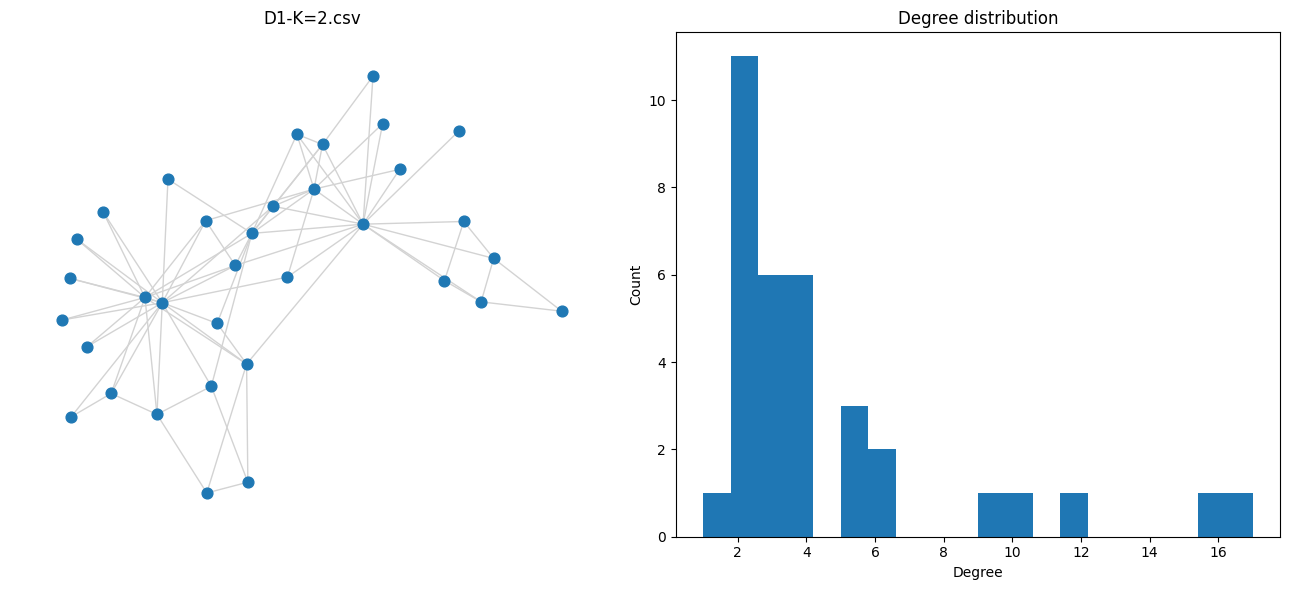

[INPUT] D1-UNC.csv: nodes=125, edges=334


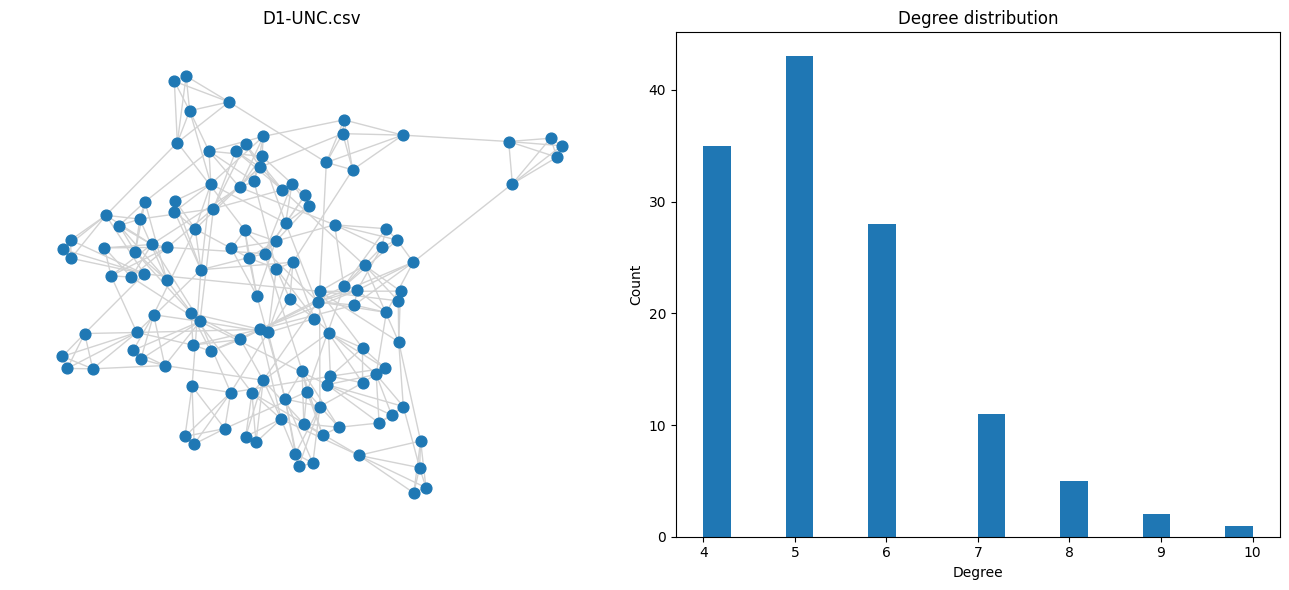

[INPUT] D2-K=7.csv: nodes=62, edges=159


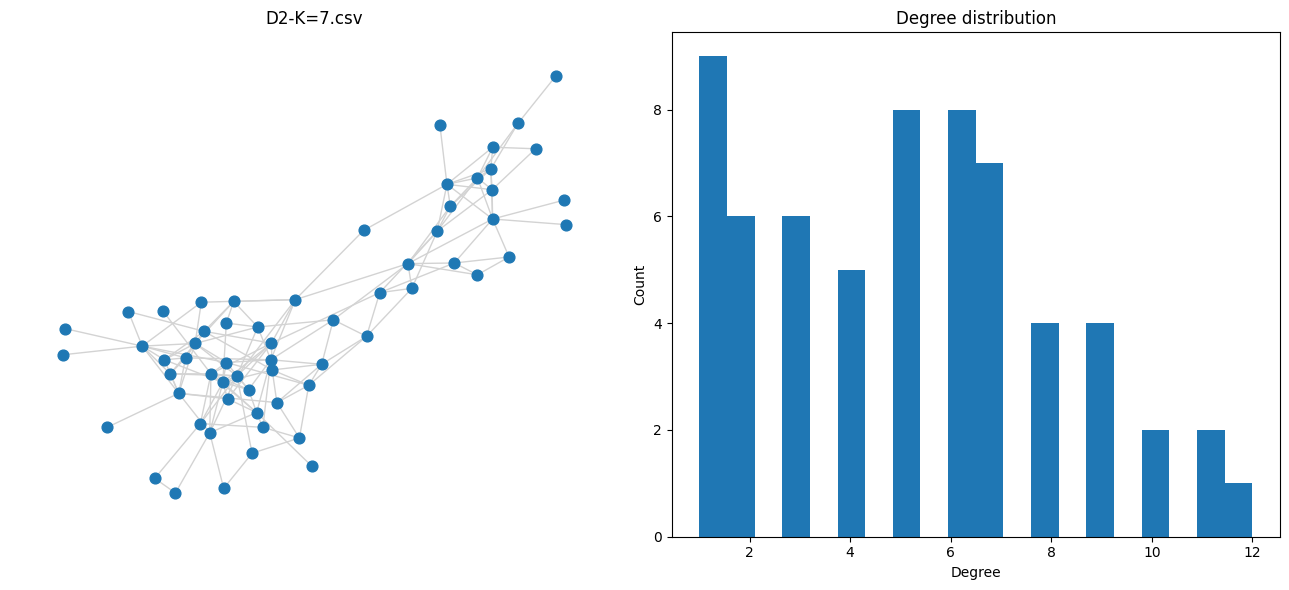

[INPUT] D2-UNC.csv: nodes=150, edges=940


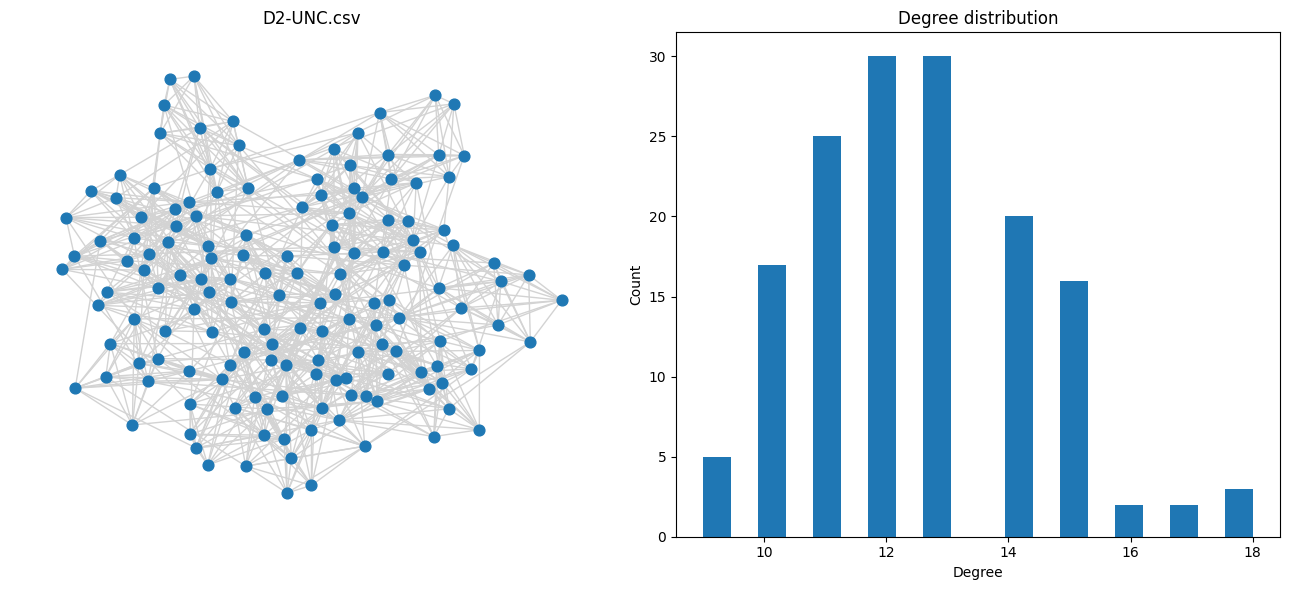

[INPUT] D3-K=12.csv: nodes=115, edges=613


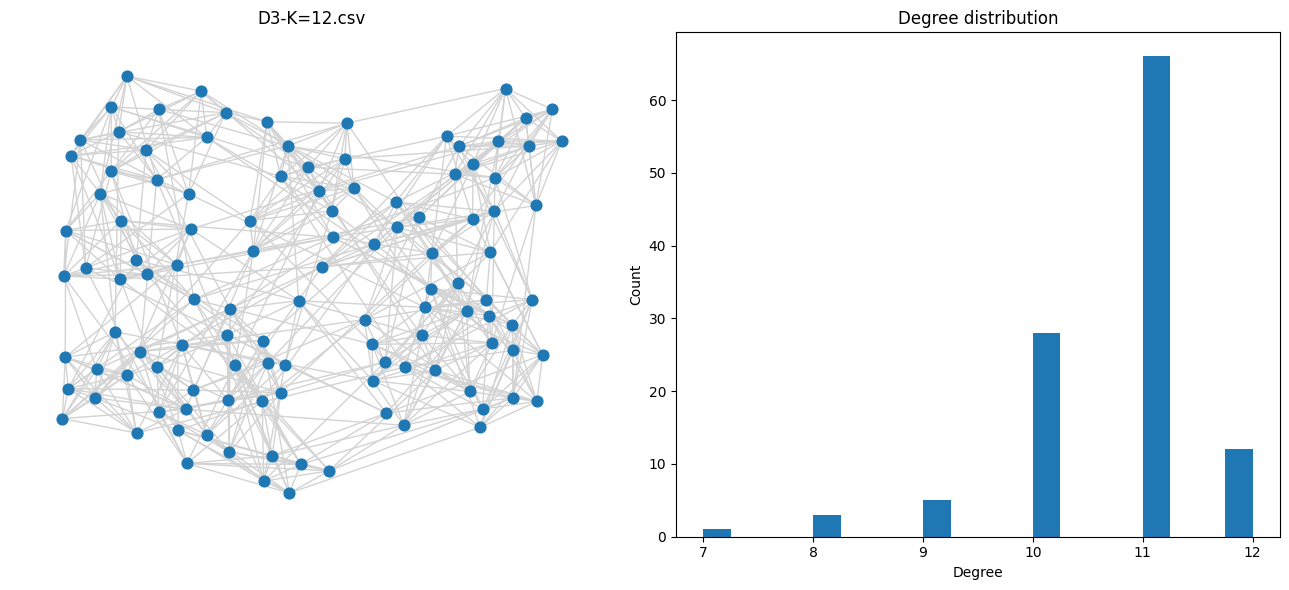

[INPUT] D3-UNC.csv: nodes=81, edges=487


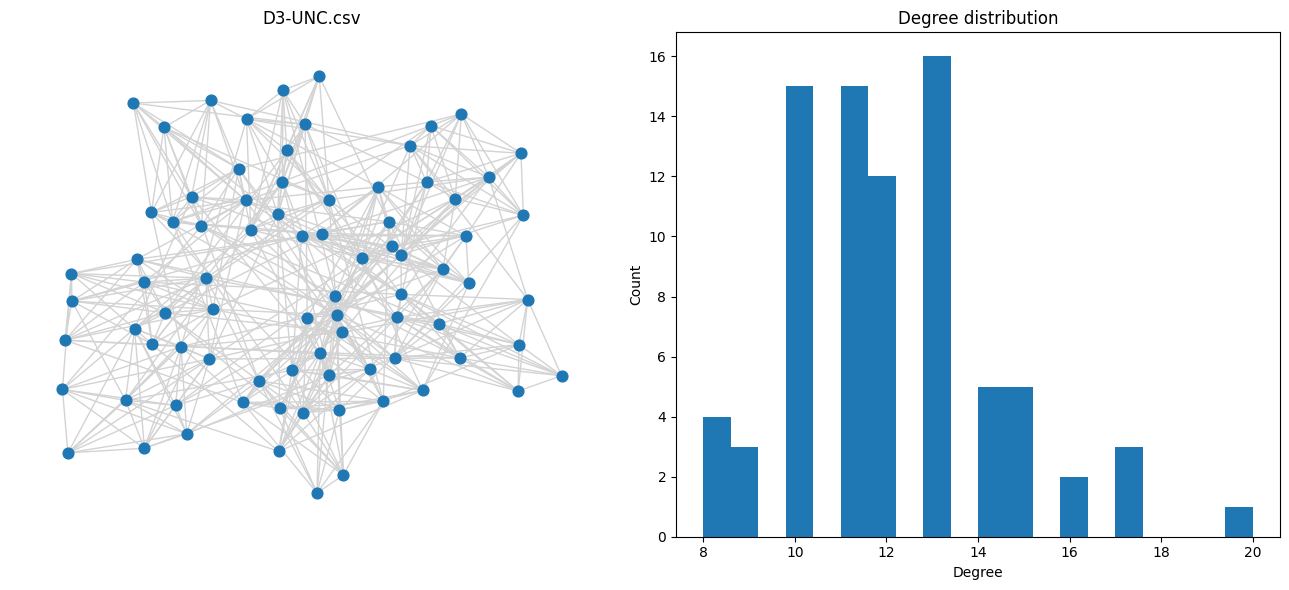

[Infomap] D1-K=2.csv | K_target=2 → K_found=2 | time=0.0131s


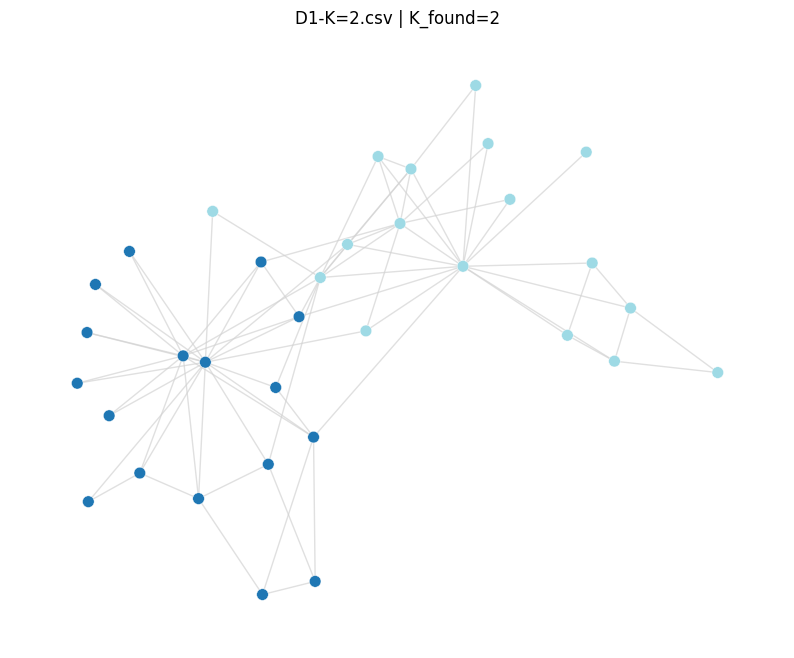

[Infomap] D1-UNC.csv | K_target=? → K_found=25 | time=0.0262s


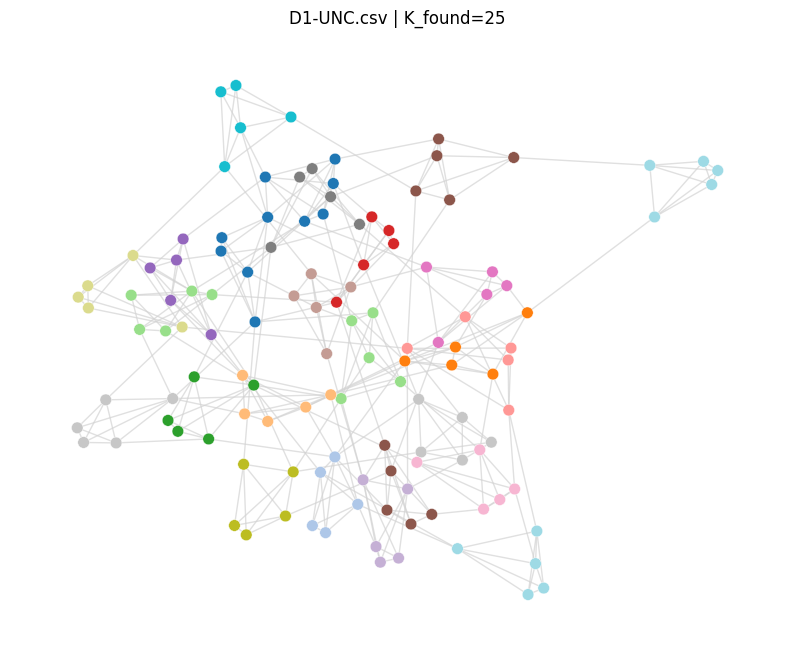

[Infomap] D2-K=7.csv | K_target=7 → K_found=7 | time=0.0261s


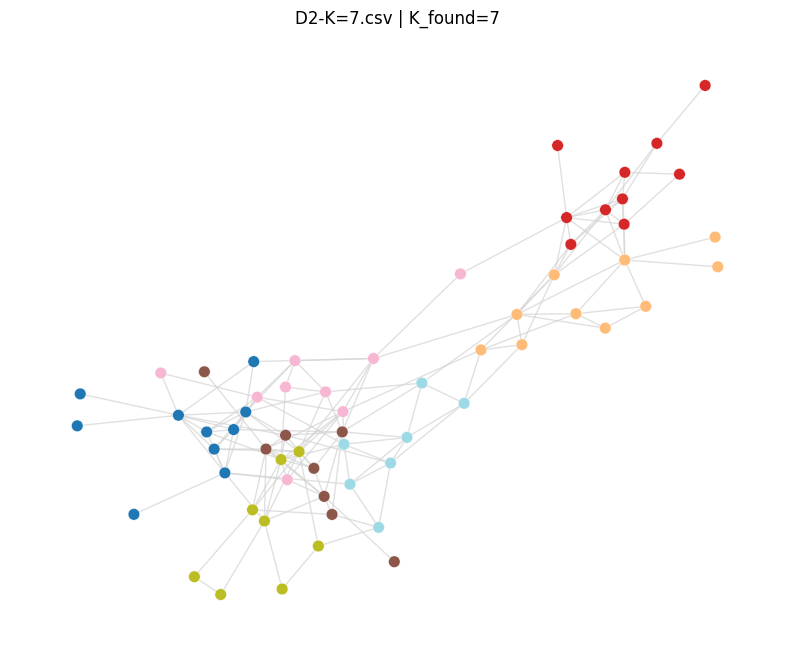

[Infomap] D2-UNC.csv | K_target=? → K_found=15 | time=0.0330s


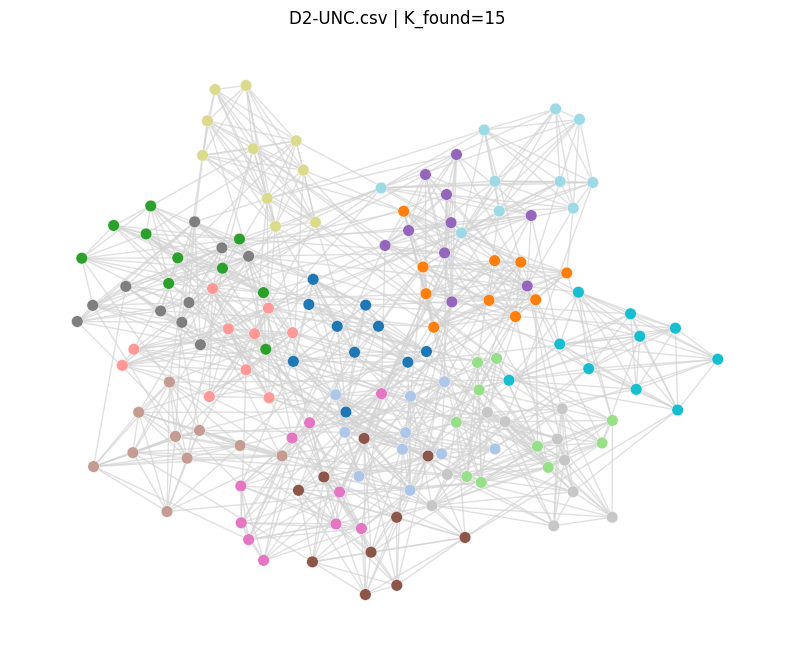

[Infomap] D3-K=12.csv | K_target=12 → K_found=12 | time=0.0575s


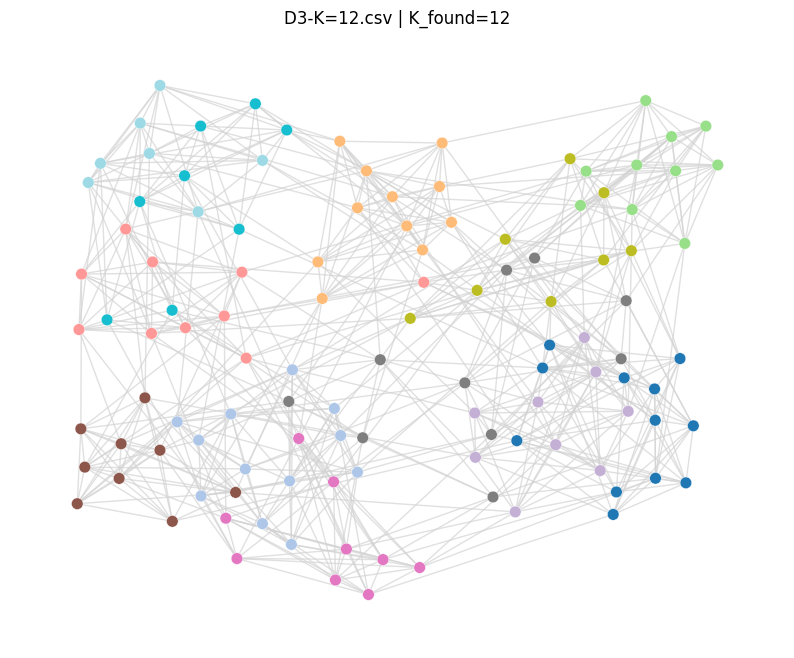

[Infomap] D3-UNC.csv | K_target=? → K_found=9 | time=0.0192s


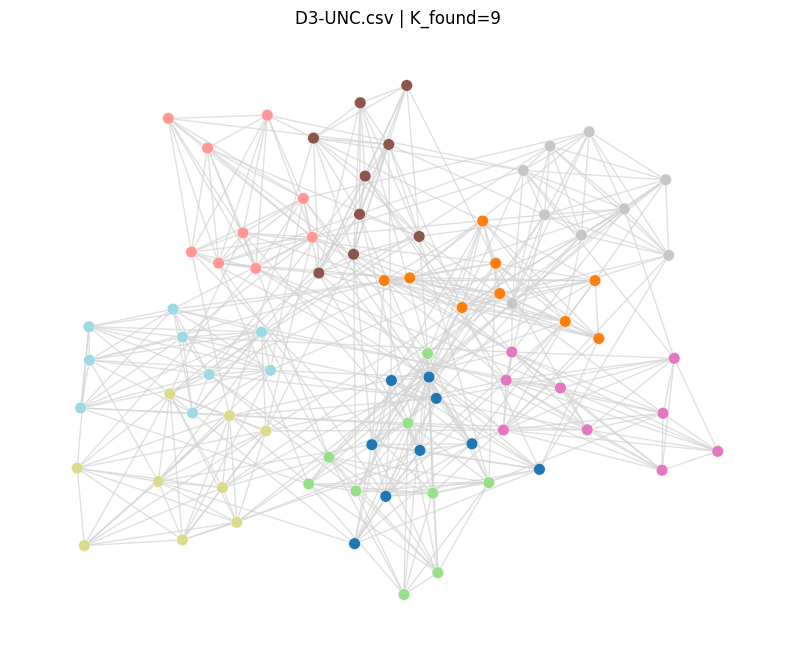


Competition results saved to: ./results


In [12]:
def main():
    files = sorted(f for f in os.listdir(INPUT_DIR) if f.endswith(".csv"))
    timings = []

    for fname in files:
        G = read_adjacency_csv(os.path.join(INPUT_DIR, fname))
        print(f"[INPUT] {fname}: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")
        show_graph_basic(G, fname)

    for fname in files:
        G = read_adjacency_csv(os.path.join(INPUT_DIR, fname))
        known_k = extract_known_k(fname)

        start = time.perf_counter()
        labels, k_found, markov_time, codelength = detect_communities(G, known_k)
        elapsed = time.perf_counter() - start
        timings.append((fname, elapsed))

        save_partition(os.path.join(OUTPUT_DIR, fname), labels)

        print(
            f"[Infomap] {fname} | "
            f"K_target={'?' if known_k is None else known_k} → K_found={k_found} | "
            f"time={elapsed:.4f}s"
        )

        show_communities(G, labels, fname)

    with open(os.path.join(OUTPUT_DIR, "description.txt"), "w") as f:
        f.write("Jakub Oganowski, Hubert Jaczynski\n")
        f.write("https://github.com/OganKuba/P10-Social\n")
        for name, t in timings:
            f.write(f"{name}, {t:.6f}\n")

    print("\nCompetition results saved to:", OUTPUT_DIR)


if __name__ == "__main__":
    main()